In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.datasets import make_classification
from statsmodels.discrete.count_model import ZeroInflatedPoisson
from statsmodels.discrete.discrete_model import NegativeBinomial

plt.style.use('ggplot')

# Generalized Linear Models (GLM)

So far, we have modeled the response variable $y$ using the ordinary least squares (OLS) method:

$y = X\beta$

$y \sim N(\mu,\ \sigma^2)$

$\epsilon \sim N(0,\ \sigma_e^2)$

What if the response variable is not continuous or normally distributed? Should we give up in those situations? That's where GLMs come into play.

GLMs expand the model equation to allow modeling these different cases. In general, GLMs introduce a *link function* $g(\cdot)$ such that the relationship can be defined as:

$g(\mu) = X\beta$

For the normal distribution, $g(\cdot)$ is nothing but the identity function:

$g(\mu) = \mu$

Any distribution that belongs to the exponential family (Normal, Binomial, Poisson, Gamma etc.) can be used in GLM modeling.

## Binomial Regression



When we need to model the number of successes out of $n$ trials, we use binomial regression. In this case,



$Y \sim \text{Binomial}(n, p)$



where $p$ refers to the probability of success. The corresponding link function $g$ is the logit:



$g(p) = \ln\left(\frac{p}{1-p}\right)$



When we combine it with the linear part, we get the model equation:



$\ln\left(\frac{p}{1-p}\right) = X\beta$



The logit function allows us to:



* Constrain probabilities between 0 and 1.

* Model the nonlinear effect of predictors on the probability of the outcome.



## Logistic Regression



Logistic regression is a special case of binomial regression where each observation is a single trial ($n = 1$, success or fail).



When we solve the logit equation for $p$, we get:



$\hat{p} = \frac{\exp(X\hat{\beta})}{1 + \exp(X\hat{\beta})}$

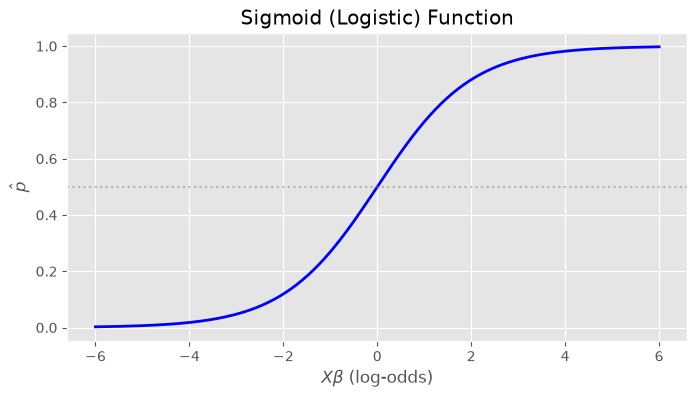

In [2]:
z = np.linspace(-6, 6, 200)
p = np.exp(z) / (1 + np.exp(z))

plt.figure(figsize=(8, 4))
plt.plot(z, p, 'b-', linewidth=2)
plt.axhline(0.5, color='gray', linestyle=':', alpha=0.5)
plt.xlabel(r'$X\beta$ (log-odds)')
plt.ylabel(r'$\hat{p}$')
plt.title('Sigmoid (Logistic) Function')
plt.show()

### Example


Let's see a binary classification example as well. To create the dataset, we will use `make_classification` function of `scikit-learn` library. For simplicity, we will use only two informative predictors.

In [3]:
X,y = make_classification(n_classes=2,
                          n_samples=1000,
                          n_features = 2,
                          n_redundant=0,
                          n_informative = 2,
                          random_state = 42)

model = sm.Logit(y,sm.add_constant(X)).fit()
print(model.summary())

Optimization terminated successfully.
         Current function value: 0.330815
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                 1000
Model:                          Logit   Df Residuals:                      997
Method:                           MLE   Df Model:                            2
Date:                Mon, 17 Aug 2026   Pseudo R-squ.:                  0.5227
Time:                        10:56:52   Log-Likelihood:                -330.81
converged:                       True   LL-Null:                       -693.14
Covariance Type:            nonrobust   LLR p-value:                4.412e-158
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2277      0.102      2.237      0.025       0.028       0.427
x1            -0.3023      0.

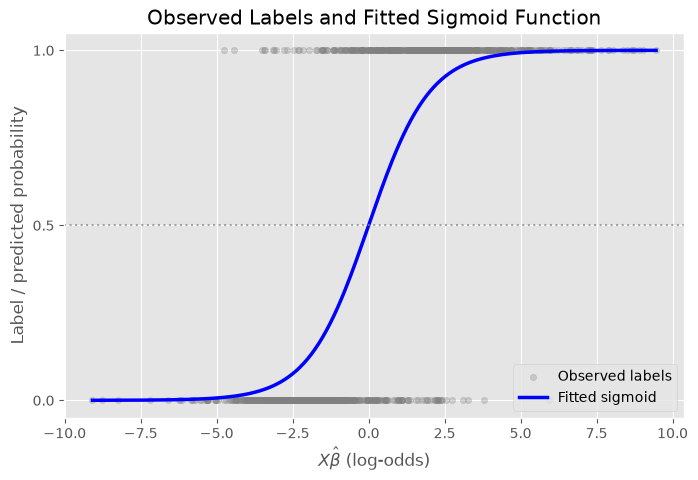

In [4]:
linear_score = sm.add_constant(X) @ model.params
score_grid = np.linspace(linear_score.min(), linear_score.max(), 300)
probability_grid = 1 / (1 + np.exp(-score_grid))

plt.figure(figsize=(8, 5))
plt.scatter(linear_score, y, alpha=0.3, s=20, label='Observed labels', color = 'grey')
plt.plot(score_grid, probability_grid, color='blue', linewidth=2.5,
         label='Fitted sigmoid')

plt.axhline(0.5, color='gray', linestyle=':', alpha=0.7)
plt.xlabel(r'$X\hat{\beta}$ (log-odds)')
plt.ylabel('Label / predicted probability')
plt.title('Observed Labels and Fitted Sigmoid Function')
plt.yticks([0, 0.5, 1])
plt.legend()

plt.show()

The logistic regression equations are:

$\hat{y} = 0.22 - 0.3x_1 + 2.17x_2$

$\hat{p} = \text{sigmoid}(\hat{y})$

Inferences:

* All the parameters have p-value less than p-critical (0.05) so we can conclude that all the variables are statistically significant.
* The results of the log likelihood test (LLR p-value) shows that current model is statistically better (-330 vs -693) than intercept only model.
* Relative effect of $x_1$ is $e^{-0.3} \approx 0.74$. Each unit increase in $x_1$ results in a 26% decrease in odds.
* Absolute effect of $x_1$ is $-0.3 \times \hat{p}(1-\hat{p}) = -0.3 \times 0.555 \times 0.445 \approx -0.074$. Each unit increase in $x_1$ decreases the probability by about 7.4%.

## Poisson Regression

Let's recall binomial regression one more time:

$Y \sim \text{Binomial}(n, p)$

$E[Y] = np$

$\sigma^2 = np(1-p)$

When the number of trials $n$ is very large and the probability of success $p$ is very small, the expected value and variance become approximately equal. This special case gives rise to Poisson regression:

$Y \sim \text{Poisson}(\lambda), \quad P(Y=k) = \frac{e^{-\lambda}\lambda^k}{k!}$


where $\lambda$ refers to the expected number of events per unit of exposure (time, area, etc.).

To keep predictions positive and model the nonlinear relationship, we use the log link:

$\log(\mu) = X\beta$

When observations have different exposure times $\tau$, we model the rate $\lambda = \mu / \tau$:

$\log(\lambda) = \log(\mu) - \log(\tau) = X\beta$

$\log(\mu) = X\beta + \log(\tau)$

The $\log(\tau)$ term is called the "offset". It accounts for differing exposure without being estimated as a parameter.

### Example

We know that accident rates are higher as we get older. Let's say we want to model this relationship. We investigated 200 people with observation periods varying from 1 to 5 years. 

$n = 200$

$\text{exposure} \sim U(1,5)$

$\text{age} \sim U(20,60)$

True relationship:

$\log(\text{accident}) = -1 + 0.03 \cdot \text{age} + \log(\text{exposure})$

In [5]:
np.random.seed(42)
n = 200

# Predictors
age = np.random.uniform(20, 60, n)
exposure = np.random.uniform(1, 5, n) 


log_mu = -1 + 0.03 * age + np.log(exposure)
y = np.random.poisson(np.exp(log_mu))

X = sm.add_constant(age)
model = sm.GLM(y, X, family=sm.families.Poisson(), offset=np.log(exposure)).fit()
print(model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:                  200
Model:                            GLM   Df Residuals:                      198
Model Family:                 Poisson   Df Model:                            1
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -402.32
Date:                Mon, 17 Aug 2026   Deviance:                       241.62
Time:                        10:56:53   Pearson chi2:                     234.
No. Iterations:                     5   Pseudo R-squ. (CS):             0.3391
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.9897      0.144     -6.868      0.0

The Poisson regression model found pretty similar coefficients to the formula we used while generating the data.

Don't be confused by the low $R^2$ value! It is different from the $R^2$ we use in Linear Regression. In fact, Poisson regression does not have a true $R^2$. Therefore, we use alternative $R^2$ measures instead, which typically yield lower values. Here is the typical interpretation:

| Pseudo R² Range | Interpretation           |
|------------------|--------------------------|
| < 0.1            | Weak fit (common in count models) |
| 0.1 – 0.2        | Moderate explanatory power |
| 0.2 – 0.4        | Good fit for Poisson data |
| > 0.4            | Rare, indicates very strong relationship or overfitting |

Many times, the variance and expected value are not the same (the variance is much higher than the expected value). Therefore, using standard Poisson regression can be misleading. To handle these situations, we use different count models.

 One reason for the variance being much larger than the expected value is an excess number of zeros in the dataset. Some of these zeros can be structural. If that is the case, we use "Zero Inflated Poisson Regression".

## Zero Inflated Poisson Regression

To use Zero Inflated Poisson Regression (ZIP), the following criteria must be met:

* Overdispersion (a fancy way of saying the variance is much higher than the mean) exists.
* There are structural zeros in the dataset.

A good example where ZIP applies is smoke counts. When collecting data, some people may never smoke at all (structural zeros), while others simply did not smoke within the observational period.

In these cases, we can fit ZIP. But before applying it, we need to understand what ZIP actually does.

ZIP simultaneously fits two models:

* **Logistic model:** To separate structural zeros from the non-structural ones.
* **Poisson model:** As a count model.

If we denote the probability of a structural zero as $\pi$, the probability of observing zero can be written as

$P(Y = 0) = \pi + (1 - \pi)e^{-\lambda}$

And the nonzero probabilities will be:


$P(Y = k) = (1 - \pi)\dfrac{e^{-\lambda}\lambda^k}{k!}, \quad k \geq 1$


To understand whether overdispersion exists, we can look at $\phi$:

$\phi = \frac {\chi^2} {dof}$



### Example

Let's say we have a sample containing both smokers and nonsmokers. We observed each individual for one week and recorded their daily cigarette consumption. We know two things about each person:

1. Their degree of health consciousness
2. Their stress levels.




$n = 1000$

$S \sim U\{1, 2, \ldots, 10\} \quad \text{(stress level)}$


$H \sim U\{1, 2, 3, 4, 5\} \quad \text{(health consciousness)}$


True relationship for the zero model (structural non-smokers):

$\log\left(\dfrac{\pi_i}{1 - \pi_i}\right) = -3.5 + 1.1 \cdot H_i$

True relationship for the count model (daily cigarettes among smokers):

$\log(\lambda_i) = 1.0 + 0.1 \cdot S_i$

In [6]:
np.random.seed(42)
n = 1000

health_conscious = np.random.randint(1, 6, n)
stress_level     = np.random.randint(1, 11, n)

log_odds_pi = -3.5 + 1.1 * health_conscious
pi_i        = 1 / (1 + np.exp(-log_odds_pi)) #sigmoid conversion

is_structural_zero = np.random.binomial(1, pi_i).astype(bool)

lambda_i       = np.exp(1.0 + 0.1 * stress_level)
poisson_counts = np.random.poisson(lambda_i)
counts = np.where(is_structural_zero, 0, poisson_counts)

df = pd.DataFrame({
    "cigarettes_per_day" : counts,
    "health_conscious"   : health_conscious,
    "stress_level"       : stress_level,
    "structural_zero"    : is_structural_zero,  #for reference
    "pi_i"               : pi_i,                #for reference
})

df.head(3)


,cigarettes_per_day,health_conscious,stress_level,structural_zero,pi_i
0,0,4,4,True,0.710950
1,0,5,4,True,0.880797
2,5,3,5,False,0.450166


Let's start with regular Poisson Regression.

In [7]:
#design matrix
X_naive = sm.add_constant(df[["stress_level", "health_conscious"]])

poisson_model  = sm.GLM(df["cigarettes_per_day"],
                        X_naive,
                        family=sm.families.Poisson())
poisson_result = poisson_model.fit()
print(poisson_result.summary())


                 Generalized Linear Model Regression Results                  
Dep. Variable:     cigarettes_per_day   No. Observations:                 1000
Model:                            GLM   Df Residuals:                      997
Model Family:                 Poisson   Df Model:                            2
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -2404.9
Date:                Mon, 17 Aug 2026   Deviance:                       3027.2
Time:                        10:56:53   Pearson chi2:                 3.19e+03
No. Iterations:                     5   Pseudo R-squ. (CS):             0.6673
Covariance Type:            nonrobust                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const                1.4615      0.058  

The summary table looks perfect. It has an exceptional $R^2$ score. All the parameters are statistically significant.

If I can give one piece of advice about model fitting, it would be "If something is extremely good, then something is wrong." And actually something is wrong in this model. Let's check the overdispersion as well as the target distribution:

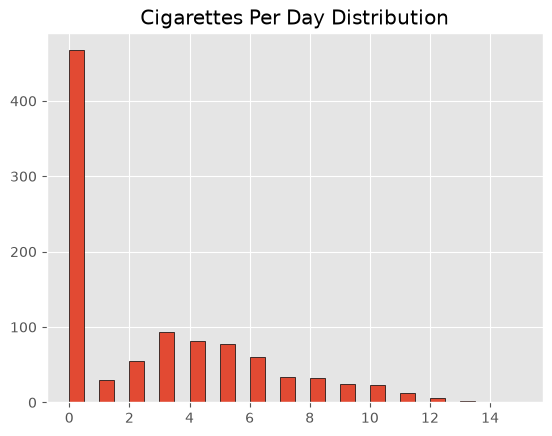

Pearson chi² : 3188.17
df residual  : 997
φ (phi)      : 3.198


In [8]:
plt.figure()
plt.hist(df["cigarettes_per_day"], bins=30, edgecolor='black')
plt.title("Cigarettes Per Day Distribution")
plt.show()

pearson_chi2 = poisson_result.pearson_chi2
df_resid     = poisson_result.df_resid
phi          = pearson_chi2 / df_resid

print(f"Pearson chi² : {pearson_chi2:.2f}")
print(f"df residual  : {df_resid}")
print(f"φ (phi)      : {phi:.3f}")

$\hat{\phi} = 3.198 \gg 1$. This means that standard errors are calculated 3.2 times smaller than they should be, which makes the z and p values unreliable. Also the histogram shows that the dataset is inflated with lots of zeros.

Since we know that there are nonsmokers (structural zeros) in our dataset, we can continue with ZIP.

Two models are required for ZIP. A question that may arise is "Which predictor to include in each model?"

To answer this question, domain expertise and AIC comparison are simultaneously used. For example, if someone is health conscious, then there is a considerable probability of being a nonsmoker. On the other hand, stress levels are much more correlated with the cigarette consumption for smokers.

Talking in hindsight is easy. We need to try different models to validate our thought process.

#### Model 1

Zero model: $H$ and $S$

Count model: $S$

In [9]:
#design matrix
X_zero = sm.add_constant(df[["health_conscious", "stress_level"]])
X_count = sm.add_constant(df[["stress_level"]])

model = ZeroInflatedPoisson(endog=df["cigarettes_per_day"],
                            exog=X_count,
                            exog_infl=X_zero,
                            inflation='logit')

results = model.fit()
print(results.summary())
print()
print("AIC score:", results.aic)

Optimization terminated successfully.
         Current function value: 1.639705
         Iterations: 17
         Function evaluations: 21
         Gradient evaluations: 21
                     ZeroInflatedPoisson Regression Results                    
Dep. Variable:      cigarettes_per_day   No. Observations:                 1000
Model:             ZeroInflatedPoisson   Df Residuals:                      998
Method:                            MLE   Df Model:                            1
Date:                 Mon, 17 Aug 2026   Pseudo R-squ.:                  0.1605
Time:                         10:56:53   Log-Likelihood:                -1639.7
converged:                        True   LL-Null:                       -1953.2
Covariance Type:             nonrobust   LLR p-value:                2.363e-138
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
in

#### Model 2

Zero model: $H$ 

Count model: $H$ and $S$

In [10]:
#design matrix
X_zero = sm.add_constant(df[["health_conscious"]])
X_count = sm.add_constant(df[["health_conscious","stress_level"]])

model = ZeroInflatedPoisson(endog=df["cigarettes_per_day"],
                            exog=X_count,
                            exog_infl=X_zero,
                            inflation='logit')

results = model.fit()
print(results.summary())
print()
print("AIC score:", results.aic)

Optimization terminated successfully.
         Current function value: 1.639637
         Iterations: 18
         Function evaluations: 21
         Gradient evaluations: 21
                     ZeroInflatedPoisson Regression Results                    
Dep. Variable:      cigarettes_per_day   No. Observations:                 1000
Model:             ZeroInflatedPoisson   Df Residuals:                      997
Method:                            MLE   Df Model:                            2
Date:                 Mon, 17 Aug 2026   Pseudo R-squ.:                  0.1605
Time:                         10:56:53   Log-Likelihood:                -1639.6
converged:                        True   LL-Null:                       -1953.2
Covariance Type:             nonrobust   LLR p-value:                6.941e-137
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
in

#### Model 3

Zero model: $H$ and $S$ 

Count model: $H$ and $S$

In [11]:
#design matrix
X_zero = sm.add_constant(df[["health_conscious", "stress_level"]])
X_count = sm.add_constant(df[["health_conscious", "stress_level"]])

model = ZeroInflatedPoisson(endog=df["cigarettes_per_day"],
                            exog=X_count,
                            exog_infl=X_zero,
                            inflation='logit')

results = model.fit()
print(results.summary())
print()
print("AIC score:", results.aic)

Optimization terminated successfully.
         Current function value: 1.639615
         Iterations: 19
         Function evaluations: 23
         Gradient evaluations: 23
                     ZeroInflatedPoisson Regression Results                    
Dep. Variable:      cigarettes_per_day   No. Observations:                 1000
Model:             ZeroInflatedPoisson   Df Residuals:                      997
Method:                            MLE   Df Model:                            2
Date:                 Mon, 17 Aug 2026   Pseudo R-squ.:                  0.1605
Time:                         10:56:53   Log-Likelihood:                -1639.6
converged:                        True   LL-Null:                       -1953.2
Covariance Type:             nonrobust   LLR p-value:                6.792e-137
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
in

#### Model 4

Zero model: $H$

Count model:  $S$

In [12]:
#design matrix
X_zero = sm.add_constant(df[["health_conscious"]])
X_count = sm.add_constant(df[["stress_level"]])

model = ZeroInflatedPoisson(endog=df["cigarettes_per_day"],
                            exog=X_count,
                            exog_infl=X_zero,
                            inflation='logit')

results = model.fit()
print(results.summary())
print("AIC score:", results.aic)

Optimization terminated successfully.
         Current function value: 1.639727
         Iterations: 14
         Function evaluations: 17
         Gradient evaluations: 17
                     ZeroInflatedPoisson Regression Results                    
Dep. Variable:      cigarettes_per_day   No. Observations:                 1000
Model:             ZeroInflatedPoisson   Df Residuals:                      998
Method:                            MLE   Df Model:                            1
Date:                 Mon, 17 Aug 2026   Pseudo R-squ.:                  0.1605
Time:                         10:56:53   Log-Likelihood:                -1639.7
converged:                        True   LL-Null:                       -1953.2
Covariance Type:             nonrobust   LLR p-value:                2.417e-138
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
in

All the models except the last one have statistically insignificant parameters. The last model did not have any and it has the lowest AIC score. Therefore, our thoughts are validated.

As you may have noticed, the parameters of the last model are pretty similar to the coefficients we used while creating the data:

Zero model:

$\log\left(\dfrac{\hat{\pi}}{1 - \hat{\pi}}\right) = -3.61 + 1.11 \cdot H$


Count model:

$\log(\hat{\lambda}) = 1.00 + 0.10 \cdot S$

Lastly, you may think that the $R^2$ score is low. Actually it isn't. In zero inflated datasets, the $R^2$ is interpreted differently:

| Pseudo R² Range  | Interpretation for zero inflated models                              |
|------------------|--------------------------------------------------------------------|
| < 0.05           | Weak fit (predictors explain very little variation)               |
| 0.05 – 0.15      | Typical and acceptable (especially datasets with many zeros)       |
| > 0.20           | Strong model (relatively rare, shows substantial explanatory power)|
| > 0.40           | Suspiciously high (may indicate overfitting or data leakage)       |



## Negative Binomial Regression

What if there are lots of zeros but none of them are structural? We can use Negative Binomial Regression in these cases. The formulas:

**PMF:**

$P(Y = y \mid \mu, \alpha) = \dbinom{y + \frac{1}{\alpha} - 1}{y} \left(\dfrac{1}{1 + \alpha\mu}\right)^{1/\alpha} \left(\dfrac{\alpha\mu}{1 + \alpha\mu}\right)^y, \quad y = 0, 1, 2, \ldots$

**Link function (log link):**

$\log(\mu_i) = \beta_0 + \beta_1 x_{1i} + \cdots + \beta_k x_{ki}$

**Mean and Variance:**

$E(Y_i) = \mu_i$

$\text{Var}(Y_i) = \mu_i + \alpha \mu_i^2$

where $\alpha \geq 0$ is the dispersion parameter. When $\alpha = 0$, the model reduces to Poisson regression.

### Example

Let's say we want to model the daily sales of nostalgic movies at shops of a global CD store chain. Many small shops likely sold no nostalgic movies at all on a given day, while some high-traffic shops may exhibit high and variable sales counts. The predictors are:

1. The shop size
2. The customer volume
3. Median age of customers


$n = 1000$

$Z \sim U\{1, 2, 3\} \quad \text{(shop size category: 1 = small, 2 = medium, 3 = large)}$

$C \sim U\{50, 51, \ldots, 500\} \quad \text{(daily customer volume)}$

$A \sim U\{25, 26, \ldots, 65\} \quad \text{(median age of customers in years)}$

True relationship (expected daily nostalgic movie sales):

$\log(\mu_i) = -3.0 + 0.8 \cdot Z_i + 0.005 \cdot C_i + 0.04 \cdot A_i$

In [13]:
np.random.seed(42)
n = 1000

shop_size       = np.random.randint(1, 4, n)           #U{1, 2, 3}
customer_volume = np.random.randint(50, 501, n)         #U{50, ..., 500}
median_age      = np.random.randint(25, 66, n)          #U{25, ..., 65}

log_mu = -3.0 + 0.8 * shop_size + 0.005 * customer_volume + 0.04 * median_age
mu_i   = np.exp(log_mu)

alpha        = 0.5                                      # dispersion parameter
r            = 1 / alpha                                # shape of Gamma
gamma_noise  = np.random.gamma(shape=r, scale=mu_i / r, size=n)
sales        = np.random.poisson(gamma_noise)

nb_df = pd.DataFrame({
    "daily_sales"      : sales,
    "shop_size"        : shop_size,
    "customer_volume"  : customer_volume,
    "median_age"       : median_age,
    "mu_i"             : mu_i,              #for reference
})

nb_df.head(3)

,daily_sales,shop_size,customer_volume,median_age,mu_i
0,26,3,296,53,20.085537
1,4,1,436,48,6.685894
2,5,3,292,27,6.958751


Let's start with fitting a regular Poisson Regression first.

In [14]:
X_nb = sm.add_constant(nb_df[["shop_size", "customer_volume", "median_age"]])

poisson_model  = sm.GLM(nb_df["daily_sales"], X_nb, family=sm.families.Poisson())
poisson_result = poisson_model.fit()

print(poisson_result.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:            daily_sales   No. Observations:                 1000
Model:                            GLM   Df Residuals:                      996
Model Family:                 Poisson   Df Model:                            3
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -4310.4
Date:                Mon, 17 Aug 2026   Deviance:                       5467.3
Time:                        10:56:53   Pearson chi2:                 5.68e+03
No. Iterations:                     5   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              -3.0615      0.065    -

Again everything looks perfect. But if you followed me until now, you already know that you shouldn't naively believe that this is the best model. Let's check $\phi$ and target variable distribution one more time.

Pearson chi² : 5678.22
Residual df  : 996
phi (φ)      : 5.7010


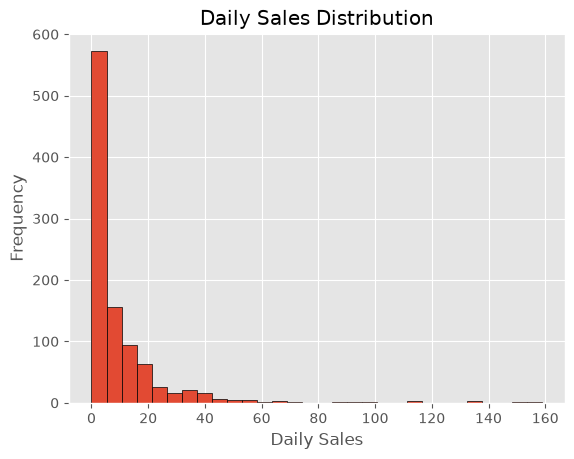

In [15]:
pearson_chi2 = poisson_result.pearson_chi2
df_resid     = poisson_result.df_resid
phi          = pearson_chi2 / df_resid

print(f"Pearson chi\u00b2 : {pearson_chi2:.2f}")
print(f"Residual df  : {df_resid}")
print(f"phi (\u03c6)      : {phi:.4f}")

plt.figure()
plt.hist(nb_df["daily_sales"], bins=30, edgecolor='black')
plt.title("Daily Sales Distribution")
plt.xlabel("Daily Sales")
plt.ylabel("Frequency")
plt.show()

Similar to the previous example, we could not use the Poisson model! Since we have no structural zeros this time, we will use Negative Binomial Regression. 

In [16]:

nb_model  = NegativeBinomial(nb_df["daily_sales"], X_nb)
nb_result = nb_model.fit()

print(nb_result.summary())

Optimization terminated successfully.
         Current function value: 2.785298
         Iterations: 18
         Function evaluations: 26
         Gradient evaluations: 26
                     NegativeBinomial Regression Results                      
Dep. Variable:            daily_sales   No. Observations:                 1000
Model:               NegativeBinomial   Df Residuals:                      996
Method:                           MLE   Df Model:                            3
Date:                Mon, 17 Aug 2026   Pseudo R-squ.:                  0.1506
Time:                        10:56:53   Log-Likelihood:                -2785.3
converged:                       True   LL-Null:                       -3279.1
Covariance Type:            nonrobust   LLR p-value:                9.165e-214
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              -2.9565  

The model fitted perfectly. All the parameters are statistically significant ($p<0.05$) and we have a pretty reasonable $R^2$ score.